# Métodos aproximados

En muchos problemas de aprendizaje por refuerzo el espacio de estados es demasiado grande
(o incluso continuo), por lo que los métodos tabulares que describiamos en el notebook anterior dejan de ser prácticos.

En los métodos tabulares aprendíamos directamente con una tabla: Q(s,a) donde para cada par estado-acción había un valor almacenado.

Sin embargo, en entornos como Acrobot-v1 donde el estado está formado por variables continuas
(ángulos y velocidades angulares) lo que provoca que el número de estados posibles sea muy grande,
 no es viable almacenar todos los valores en una tabla.

Para resolver este problema utilizamos aproximación de funciones.

La idea es aprender una función parametrizada que aproxime la función valor-acción: q̂(s,a,w) ≈ qπ(s,a)
donde:
- s es el estado
- a es la acción
- w es el vector de parámetros del modelo

De esta forma, el agente no memoriza valores para cada estado concreto,
sino que aprende un modelo que generaliza entre estados similares.

En este notebook compararemos dos enfoques distintos de aproximación:

• **SARSA semi-gradiente con Tile Coding**  
• **Deep Q-Learning (DQN) con redes neuronales**

Ambos métodos nos permiten aplicar aprendizaje por refuerzo en problemas con espacios de estados continuos o de gran dimensión.

In [ ]:
# Importamos las librerías necesarias
from src.agents import AgentDeepQLearning, AgentSemiGradientSARSA
import gymnasium as gym
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from gymnasium.wrappers import RecordVideo
from pathlib import Path
from IPython.display import Video, display


# Fijamos la semilla para reproducibilidad del experimento
seed = 42
np.random.seed(seed)
np.random.default_rng(seed)

# Fijamos la semilla en Gymnasium para reproducibilidad del experimento
def make_env(env_name):
    env = gym.make(env_name, render_mode='None')
    env.reset(seed=seed)
    env.action_space.seed(seed)
    env.observation_space.seed(seed)
    return env

# Fijamos el número de episodios con el cual vamos a entrenar
n_episodes = 10000

# Métricas utilizadas

Para comparar el comportamiento de los distintos agentes durante el entrenamiento
se usan las siguientes tres métricas:

## Proporción acumulada de éxitos

La cual mide la fracción de episodios completados con éxito hasta el episodio \(t\):

($
\text{ratio}(t) =
\frac{\sum_{i=1}^{t} \mathbb{1}(\text{éxito}_i)}{t}
$)

Gracias a esta métrica podemos visualizar: 

- Si el agente converge a una política que resuelve el entorno.
- Que algoritmo aprende antes.

## Longitud del episodio (número de pasos)

Indica cuántos pasos necesita el agente para terminar un episodio.

- Si el agente aprende una buena estrategia, normalmente necesita menos pasos.
- Además en algunos entornos, cuando el episodio termina antes es porque el agente alcanza el objetivo (éxito), este es el caso de acrobot.


## Media acumulada del return

Aproxima el rendimiento esperado de la política:

($
J(\pi) = \mathbb{E}[G_t]
$)

En el entrenamiento se muestra la media acumulada del return, que actúa como
un promedio histórico del rendimiento.

Esto permite:

- observar la tendencia global del aprendizaje,
- comparar **estabilidad entre algoritmos**,
- evitar usar *moving averages* adicionales.

En conjunto, estas tres métricas nos permiten visualizar lo esperado
por la teoría de control en MDPs: una política mejor maximiza el retorno esperado
y reduce el comportamiento erroneo durante la interacción con el entorno.

In [ ]:


# Visualizamos la proporción acumulada de éxitos
def plot_success_ratio(final_results):
    
    plt.figure(figsize=(8, 4))
    
    # Iteramos sobre cada agente almacenado en el diccionario final_results
    for name, data in final_results.items():
        
        successes = np.array(data["list_stats_success"])
        
        # Calculamos la proporción acumulada de éxitos
        cumulative_ratio = np.cumsum(successes) / np.arange(1, len(successes) + 1)
        
        # Dibujamos la curva de este agente
        # label=name nos permite identificar cada agente en la leyenda
        plt.plot(cumulative_ratio, label=name)

    plt.title("Proporción acumulada de éxitos")
    plt.xlabel("Episodio")
    plt.ylabel("Proporción de éxitos")
    plt.grid(True)

    # Activamos a leyenda para distinguir qué línea corresponde a cada agente
    plt.legend()

    # Mostramos la gráfica
    plt.show()


# Gráfica 2: Longitud de episodios (número de pasos)
def plot_episode_length(final_results):

    plt.figure(figsize=(10, 5))
    
    for name, data in final_results.items():
        
        # Obtenemos la longitud de cada episodio (steps)
        y = np.array(data["episode_lengths"], dtype=float)
        
        # Obtenemos los índices de episodio
        x = np.arange(len(y))
        
        # Dibujamos la evolución del número de pasos por episodio
        plt.plot(x, y, label=name, alpha=0.6)

    plt.title("Longitud de episodios")
    plt.xlabel("Episodio")
    plt.ylabel("Steps")

    plt.grid(True)
    plt.legend()
    plt.show()

# Gráfica 3: Media acumulada del return
def plot_global_avg(final_results):

    plt.figure(figsize=(8, 4))
    
    for name, data in final_results.items():
        
        # Obtenemos list_stats que contiene la media acumulada del retorno
        list_stats = data["list_stats"]
        
        # Índices de episodio
        indices = list(range(len(list_stats)))
        
        # Dibujamos la evolución del return medio acumulado
        plt.plot(indices, list_stats, label=name)

    plt.title("Media acumulada del return")
    plt.xlabel("Episodio")
    plt.ylabel("Return medio acumulado")

    plt.grid(True)
    plt.legend()
    plt.show()


def plot_all_results(final_results):
    
    # Llamamos a las tres funciones de visualización para poder llamarlas todas a la vez
    plot_success_ratio(final_results)
    plot_episode_length(final_results)
    plot_global_avg(final_results)

# Entorno en el que trabajamos: Acrobot-v1

El entorno que hemos decidido usar es **Acrobot-v1**, de la librería Gymnasium.

Este entorno es perfecto para estudiar métodos con
aproximación de funciones, ya que el estado está definido mediante
variables continuas (ángulos y velocidades angulares). 

Debido al espacio continuo de los estados, los métodos
tabulares son insuficientes, por lo que es necesario utilizar
aproximadores de funciones (como tile coding o redes neuronales)
para estimar la función valor-acción.

## ¿Qué es Acrobot?

Acrobot es un sistema dinámico compuesto por **dos eslabones conectados
por articulaciones**, similar a un **péndulo doble.

El objetivo del agente es realizar un movimiento de balanceo hacia arriba para que
el extremo del segundo eslabón alcance una altura determinada.

Una característica importante del sistema es que el agente solo puede aplicar torque en la segunda articulación y la primera se mueve de forma pasiva por la dinámica del sistema.

## Estado (observación)

El estado del entorno está formado por seis variables:

($
s = [\cos(\theta_1), \sin(\theta_1), \cos(\theta_2), \sin(\theta_2), \dot\theta_1, \dot\theta_2]
$)




donde:

- ($ \theta_1$) y ($ \theta_2$) son los ángulos de los dos eslabones
- ($\dot\theta_1$) y ($\dot\theta_2$) son sus velocidades angulares

Los ángulos no se devuelven directamente, sino mediante sus valores de
**seno y coseno**.

## Acciones

El espacio de acciones es **discreto** y consta de tres posibles torques
aplicados a la segunda articulación:

- **-1** → torque negativo  
- **0** → sin torque  
- **+1** → torque positivo  


## Recompensa y terminación

El entorno penaliza cada paso con una recompensa:

- **-1 por paso**

El episodio termina cuando:

- el extremo del segundo eslabón alcanza la altura objetivo, o
- se alcanza el número máximo de pasos del episodio.


## Referencias

- Farama Foundation.  
  *Gymnasium Documentation – Acrobot-v1 Environment*.  
  https://gymnasium.farama.org/environments/classic_control/acrobot/

- Sutton, R. S., & Barto, A. G. (2018).  
  *Reinforcement Learning: An Introduction (2nd ed.)*. MIT Press.

- Spong, M. W. (1994).  
  *Swing up control of the Acrobot*.  
  IEEE International Conference on Robotics and Automation.

#Algoritmos comparados: SARSA semigradiente vs Deep Q-Learning

En este notebook se entrenaron los siguientes agentes:

- **SARSA Semigradiente (on-policy con aproximación)**
- **Deep Q-Learning (off-policy con red neuronal)**


## SARSA Semigradiente
SARSA es un método TD on-policy. Como vimos en el anterior notebook su forma tabular tiene la siguiente forma:

($
Q(s,a) \leftarrow Q(s,a) + \alpha \left[r + \gamma Q(s',a') - Q(s,a)\right]
$)

En aproximación de funciones, ya no actualizamos una tabla, debido al espacio continuo, sino que actualizamos parámetros ($w$).  
La actualización que realizamos es la semigradiente:

($
\mathbf{w} \leftarrow \mathbf{w} + \alpha \, \delta \, \nabla_{\mathbf{w}} \hat{q}(s,a;\mathbf{w})
$)

donde el error TD viene dado por:

($
\delta = r + \gamma \hat{q}(s',a';\mathbf{w}) - \hat{q}(s,a;\mathbf{w})
$)

Se llama *semi-gradiente* porque el objetivo también depende de ($w$), pero el gradiente se toma solo sobre la predicción actual.  
Esta formulación aparece en las transparencias de **control con aproximaciones**. 



## Deep Q-Learning 

Q-Learning es un método off-policy, en su forma tabular actualiza q de la siguiente forma:

($
Q(s,a) \leftarrow Q(s,a) + \alpha \left[r + \gamma \max_{a'} Q(s',a') - Q(s,a)\right]
$)

En Deep Q-Learning se sustituye \(Q\) por una red neuronal ($\hat{q}(s,a;\mathbf{w})$).  



In [ ]:
# Creamos un entorno independiente para cada agente
envSarsaSemigrad = make_env("Acrobot-v1")
envDeepQLearning = make_env("Acrobot-v1")

# Inicializamos los agentes
agentSarsaSemigrad = AgentSemiGradientSARSA(envSarsaSemigrad, alpha=0.2, decay_c=400)
agentDeepQLearning = AgentDeepQLearning(envDeepQLearning, epsilon=0.4, discount_factor=1.0)

step_display = n_episodes // 10 

agents_and_envs = [
    ("Sarsa Semigradiente", agentSarsaSemigrad, envSarsaSemigrad),
    ("Deep QLearning", agentDeepQLearning, envDeepQLearning),
]

# Definimos diccionario donde guardaremos los resultados obtenidos con los agentes
final_results = {}

print(f"Iniciando entrenamiento de {len(agents_and_envs)} agentes...")

for episode in tqdm(range(n_episodes)):
    
    for name, agent, env in agents_and_envs:
        
        # Reiniciamos el entorno al inicio del episodio para obtener más diversidad 
        state, info = env.reset(seed=seed)
        done = False
        
        # En SARSA necesitamos elegir la primera acción antes del bucle (on-policy)
        action = agent.get_action(state)
        
        while not done:
            
            # Ejecutamos la acción 
            next_state, reward, terminated, truncated, info = env.step(action)
            
            # Actualizamos el agente con la transición observada
            res = agent.update(state, action, next_state, reward, terminated, truncated, info)
            
            # Si update no devuelve acción como en DQN (off-policy), la calculamos
            next_action = res if res is not None else agent.get_action(next_state)
                        
            # Pasamos al siguiente estado y acción
            state = next_state
            action = next_action 
            
            done = terminated or truncated
            
        # Mostramos progreso c
        if episode % step_display == 0 and episode != 0:
            current_success = agent.list_stats_success[-1] if hasattr(agent, 'list_stats_success') else 0
            print(f"[{name}] Ep: {episode} | Success Rate: {current_success:.2f} | Eps: {agent.epsilon:.3f}")

# Guardamos resultados finales de cada agente
for name, agent, env in agents_and_envs:
    
    results = agent.get_stats()
    
    final_results[name] = {
        "Q": results[0],
        "list_stats": results[1],
        "episode_lengths": results[2],
        "list_stats_success": results[3]
    }
    
    env.close()

print("Entrenamiento completado y entornos cerrados.")

c:\Users\USUARIO\Desktop\EML\P1\emlenv\Lib\site-packages\gymnasium\envs\registration.py:728: UserWarning: WARN: The environment is being initialised with render_mode='None' that is not in the possible render_modes (['human', 'rgb_array']).
  logger.warn(


Iniciando entrenamiento de 2 agentes...


 10%|█         | 1000/10000 [09:36<1:06:20,  2.26it/s]

[Sarsa Semigradiente] Ep: 1000 | Success Rate: 1.00 | Eps: 0.400


 10%|█         | 1001/10000 [09:36<1:01:28,  2.44it/s]

...

[Deep QLearning] Ep: 8000 | Success Rate: 1.00 | Eps: 0.010


 90%|█████████ | 9000/10000 [57:29<04:55,  3.38it/s]

[Sarsa Semigradiente] Ep: 9000 | Success Rate: 1.00 | Eps: 0.044
[Deep QLearning] Ep: 9000 | Success Rate: 1.00 | Eps: 0.010


100%|██████████| 10000/10000 [1:03:07<00:00,  2.64it/s]

Entrenamiento completado y entornos cerrados.


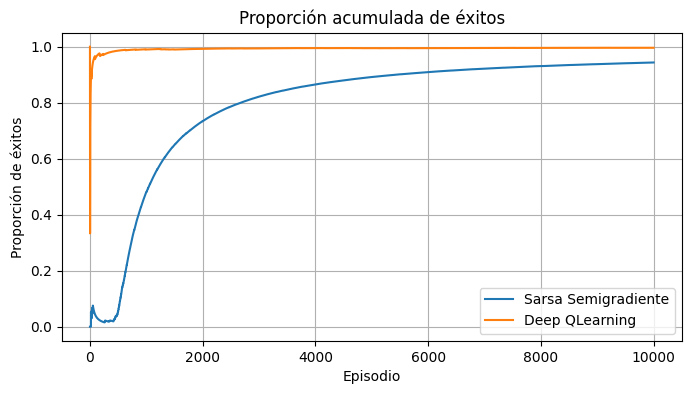

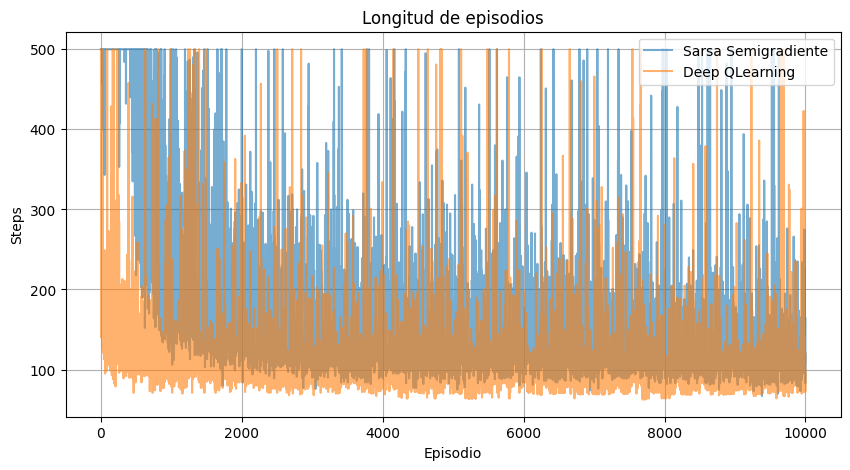

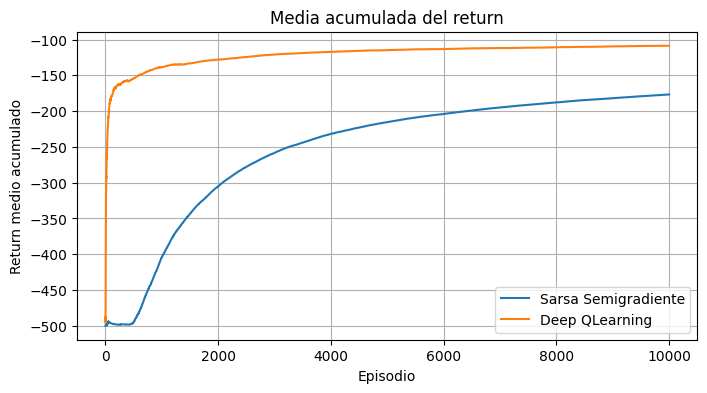

In [8]:
plot_all_results(final_results)

## Análisis de la proporción acumulada de éxitos

La gráfica muestra la evolución de la **proporción acumulada de episodios exitosos**
durante el entrenamiento para dos algoritmos:

- **SARSA Semigradiente**
- **Deep Q-Learning (DQN)**

Esta métrica indica qué fracción de episodios hasta el episodio \(t\) han terminado
con éxito. Por tanto, permite evaluar **la capacidad del agente para aprender una
política que resuelva el entorno**.


### Comportamiento de Deep Q-Learning

El agente basado en **Deep Q-Learning** muestra una mejora muy rápida.

Observaciones principales:

- En los **primeros episodios** la tasa de éxito aumenta rápidamente.
- La curva alcanza valores cercanos a **1.0** en muy pocos episodios.
- A partir de ese punto la curva se estabiliza, indicando que el agente resuelve
el entorno de forma consistente.

Esto sugiere que el agente aprende **una política efectiva en muy poco tiempo**
y mantiene un comportamiento estable durante el resto del entrenamiento.


### Comportamiento de SARSA Semigradiente

El agente basado en **SARSA semigradiente** presenta un aprendizaje más gradual.

Observaciones:

- En los primeros episodios la proporción de éxitos es cercana a **0**.
- La mejora aparece de forma progresiva tras varios cientos de episodios.
- Finalmente la tasa de éxito se aproxima a **0.95**, aunque la convergencia
es más lenta que en DQN.

Este comportamiento es esperable, ya que SARSA utiliza **aproximación lineal**
y aprende directamente de las transiciones observadas sin mecanismos como
experience replay.


### Comparación entre algoritmos

La comparación muestra diferencias claras en **velocidad de aprendizaje**:

| Algoritmo | Velocidad de aprendizaje | Proporción final |
|-----------|--------------------------|------------------|
| SARSA Semigradiente | Más lenta | ~0.95 |
| Deep Q-Learning | Muy rápida | ~1.0 |

Deep Q-Learning converge mucho antes y alcanza una tasa de éxito prácticamente
perfecta, mientras que SARSA mejora de forma más progresiva.


### Conclusión

Ambos métodos consiguen aprender una política capaz de resolver el entorno,
pero **Deep Q-Learning lo hace con mayor rapidez**. Esto refleja la mayor
capacidad de representación de los aproximadores no lineales utilizados en DQN
(frente a la aproximación lineal utilizada por SARSA semigradiente).

## Análisis de la longitud de los episodios

Esta gráfica muestra el **número de pasos necesarios para completar cada episodio**
durante el entrenamiento de los dos agentes:

- **SARSA Semigradiente**
- **Deep Q-Learning (DQN)**

La longitud del episodio es una métrica útil porque refleja **la eficiencia de la
política aprendida**. En este entorno, resolver la tarea en menos pasos suele indicar
que el agente ha aprendido una estrategia más efectiva.

---

### Comportamiento de Deep Q-Learning

El agente basado en **Deep Q-Learning** muestra una reducción rápida en la longitud
de los episodios durante las primeras etapas del entrenamiento.

Observaciones principales:

- En los primeros episodios los valores son relativamente altos.
- Con el entrenamiento, la longitud media de los episodios disminuye y se estabiliza
en torno a valores cercanos a **80–100 pasos**.
- Aunque aparecen algunos picos ocasionales, la tendencia general se mantiene estable.

Esto sugiere que el agente aprende rápidamente una política capaz de alcanzar el
objetivo de forma eficiente.

---

### Comportamiento de SARSA Semigradiente

El agente basado en **SARSA semigradiente** presenta una mayor variabilidad.

Observaciones:

- La longitud de los episodios es más irregular durante todo el entrenamiento.
- Aparecen numerosos episodios con valores altos, incluso cercanos al límite máximo.
- Aunque la tendencia general también mejora con el tiempo, la convergencia es
más lenta y menos estable.

Esto indica que el agente encuentra políticas útiles, pero su comportamiento es
más sensible a la exploración y a la variabilidad del aprendizaje.

---

### Comparación entre algoritmos

En comparación directa:

- **Deep Q-Learning** alcanza episodios más cortos de forma más consistente.
- **SARSA semigradiente** presenta mayor dispersión en la longitud de los episodios.

Esto sugiere que el agente basado en redes neuronales aprende **políticas más
eficientes y estables** en este entorno.

---

### Conclusión

La evolución de la longitud de los episodios refuerza los resultados observados
en la proporción de éxitos: **Deep Q-Learning converge más rápido y mantiene un
comportamiento más estable**, mientras que SARSA semigradiente mejora de forma
más gradual y presenta mayor variabilidad durante el entrenamiento.

## Análisis de la media acumulada del return

Esta gráfica muestra la evolución de la **media acumulada del return**
durante el entrenamiento para ambos agentes:

- **SARSA Semigradiente**
- **Deep Q-Learning (DQN)**

El return acumulado refleja el **rendimiento esperado de la política**.
En este entorno cada paso recibe una recompensa de **-1**, por lo que:

- valores más cercanos a **0** indican episodios más cortos,
- valores más negativos indican que el agente tarda más pasos en resolver el entorno.

Por tanto, **una mejora del return significa que el agente está aprendiendo
a alcanzar el objetivo en menos pasos**.

---

### Comportamiento de Deep Q-Learning

El agente basado en **Deep Q-Learning** mejora rápidamente su rendimiento.

Observaciones principales:

- En los primeros episodios el return es muy negativo (alrededor de -500),
lo que indica episodios largos.
- Tras pocos episodios se observa una mejora muy rápida.
- La curva se estabiliza aproximadamente en torno a **-110**, lo que indica
episodios significativamente más cortos.

Esto sugiere que el agente aprende rápidamente una política eficiente
para resolver el entorno.

---

### Comportamiento de SARSA Semigradiente

El agente basado en **SARSA semigradiente** presenta un aprendizaje
más gradual.

Observaciones:

- Al inicio el return también es cercano a **-500**, indicando episodios largos.
- La mejora es progresiva a lo largo del entrenamiento.
- La curva se estabiliza aproximadamente cerca de **-180**.

Aunque el agente mejora de forma clara, el rendimiento final es
inferior al obtenido por Deep Q-Learning.

---

### Comparación entre algoritmos

Comparando ambas curvas se observa que:

- **Deep Q-Learning mejora mucho más rápido** en las primeras fases del entrenamiento.
- El rendimiento final de **DQN es mejor**, ya que alcanza returns menos negativos.
- **SARSA semigradiente aprende más lentamente** y converge a una política
menos eficiente.

Estos resultados son consistentes con lo observado en las gráficas de
éxitos y longitud de episodios.

---

### Conclusión

La media acumulada del return confirma que **Deep Q-Learning aprende
políticas más eficientes en este entorno**, alcanzando episodios más
cortos y un rendimiento final superior.

SARSA semigradiente también consigue mejorar su política, pero requiere
más episodios de entrenamiento y converge a un rendimiento inferior.

In [ ]:
# Graba un vídeo de 1 episodio mostrando el comportamiento del agente en Acrobot segun el agente implementado
def record_agent_acrobot(agent, name_prefix: str, filepath: str = "./video_acrobot",
                         env_id: str = "Acrobot-v1", seed: int = 42, max_steps: int = 500):
 
    Path(filepath).mkdir(parents=True, exist_ok=True)

    # Entorno con render RGB
    env_video = gym.make(env_id, render_mode="rgb_array")
    env_video.reset(seed=seed)

    # Wrapper para grabar vídeo
    env_video = RecordVideo(
        env_video,
        video_folder=filepath,
        name_prefix=name_prefix,
        episode_trigger=lambda e: True, 
        disable_logger=True
    )

    # Evaluación sin exploración
    old_eps = getattr(agent, "epsilon", None)
    if old_eps is not None:
        agent.epsilon = 0.0

    state, _ = env_video.reset(seed=seed)
    total_reward = 0.0
    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated) and steps < max_steps:

        if hasattr(agent, "get_greedy_action"):
            action = agent.get_greedy_action(state)  
        else:
            action = agent.get_action(state)         

        state, reward, terminated, truncated, _ = env_video.step(action)
        total_reward += reward
        steps += 1

    env_video.close()

    if old_eps is not None:
        agent.epsilon = old_eps

    print(f"Vídeo guardado en: {filepath}")

    mp4s = sorted(Path(filepath).glob(f"{name_prefix}*.mp4"),
                  key=lambda p: p.stat().st_mtime, reverse=True)

    if len(mp4s) > 0:
        display(Video(str(mp4s[0]), embed=True, width=520))
    else:
        print("No se encontró el vídeo. Revisa el wrapper RecordVideo y permisos de escritura.")



# SARSA semigradiente (evaluación greedy)
print("Ejecucion de sarsa semigradiente")
record_agent_acrobot(agentSarsaSemigrad, name_prefix="acrobot-sarsa-semi-gradiente", filepath="./video_acrobot", seed=seed)

# Deep Q-Learning
print("Ejecucion de deep q learning")

record_agent_acrobot(agentDeepQLearning, name_prefix="acrobot-dqn", filepath="./video_acrobot", seed=seed)


Ejecucion de sarsa semigradiente


c:\Users\USUARIO\Desktop\EML\P1\emlenv\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\USUARIO\Desktop\EML\P1\aprendizaje-por-refuerzo-EML\Entornos_Complejos\video_acrobot folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Return del episodio grabado: -117.0 | Steps: 118
Vídeo guardado en: ./video_acrobot


Ejecucion de deep q learning
Return del episodio grabado: -119.0 | Steps: 120
Vídeo guardado en: ./video_acrobot
